In [1]:
import pandas as pd
import geopandas as gpd


## Import Data

In [2]:
fes2024_winter_peak = pd.read_csv("../Data/Demand/FES_2425_winter_peak.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../Data/Demand/FES_2425_winter_peak.csv'

In [ ]:
fes2024_winter_peak.head()

,Elexon ID,Name,Minor FLOP,Major FLOP,P(Gross),Q Gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Dx Storage Demand,Micro storage Demand
0,ABHA1,Abham,F6,F,329.998528,0.884376,-20.860707,60.717,212.007,0.988,1.917,97.242,0,0
1,ABNE_P,Abernethy,T4,T,38.702785,-0.688556,-2.012223,0.239,26.904,18.833,0.129,0.000,0,0
2,ABTH_1,Aberthaw,H2,H,174.139940,8.653586,-32.728783,0.540,108.668,0.545,0.000,29.537,0,0
3,ACTL_2,Acton Lane 66kV,A7,A,24.658002,-2.236142,-2.761841,0.142,5.303,0.000,0.279,0.363,0,0
4,ACTL_C,Acton Lane 22kV,A7,A,33.985529,0.442958,-3.806579,0.000,0.000,0.000,0.000,0.000,0,0


In [ ]:
# import grid supply point locations
gsp_points = gpd.read_file("../Data/Network/fes2024_regional_breakdown_gsp_info.csv")
gsp_points["geometry"] = gpd.points_from_xy(gsp_points.Longitude, gsp_points.Latitude)
gsp_points = gpd.GeoDataFrame(gsp_points, geometry="geometry", crs="EPSG:4326")
gsp_points[["Longitude", "Latitude"]] = gsp_points[["Longitude", "Latitude"]].astype(float)

# major flop is the first letter of major flop
gsp_points["Major FLOP"] = gsp_points["Minor FLOP"].astype(str).str[0]

# convert to british national grid
gsp_points = gsp_points.to_crs(epsg=27700)

In [ ]:
gsp_points.head()

,GSP ID,GSP Group,Minor FLOP,Name,Latitude,Longitude,Comments,geometry,Major FLOP
0,ABNE_P,_P,T4,Abernethy,56.339,-3.294,,POINT (320102.759 717046.167),T
1,ABTH_1,_K,H2,Aberthaw,51.385,-3.403,,POINT (302465.756 166040.527),H
2,ABHA1,_L,F6,Abham,50.472,-3.729,,POINT (277402.589 65005.199),F
3,ACTL_C,_C,A7,Acton Lane 22kV,51.535,-0.257,,POINT (520988.085 183227.707),A
4,ACTL_2,_H,A7,Acton Lane 66kV,51.535,-0.257,,POINT (520988.085 183227.707),A


In [ ]:
gsp_polygons = gpd.read_file("../Data/Geospatial/GSP_regions_4326_20250109.geojson")
gsp_polygons.crs = "EPSG:4326"
gsp_polygons = gsp_polygons.to_crs(epsg=27700)


In [ ]:
# Separate pipe-delimited GSPs into separate rows
gsp_polygons["GSPs"] = gsp_polygons["GSPs"].str.split("|")
gsp_polygons = gsp_polygons.explode("GSPs").reset_index(drop=True)

# Fill in missing Minor FLOP and Major FLOP data from gsp_points
# Drop the existing FLOP columns from the merge (they may have NaN values)
gsp_polygons = gsp_polygons.drop(columns=["GSP ID", "Major FLOP", "Minor FLOP"], errors="ignore")

# Merge again with gsp_points to get complete FLOP data
gsp_polygons = gsp_polygons.merge(
    gsp_points[["GSP ID", "Major FLOP", "Minor FLOP", "GSP Group"]], 
    left_on="GSPs", 
    right_on="GSP ID", 
    how="left"
)

In [ ]:
gsp_polygons.head()

,GSPs,GSPGroup,geometry,GSP ID,Major FLOP,Minor FLOP,GSP Group
0,NETS,_N,"MULTIPOLYGON (((243392.631 589698.709, 255939....",NETS,S,S6,_N
1,CHAP,_N,"MULTIPOLYGON (((331236.338 565048.182, 331214....",CHAP,S,S6,_N
2,BISW_1,_E,"MULTIPOLYGON (((311775.048 281560.56, 311722.7...",BISW_1,L,L2,_E
3,PORD,_N,"MULTIPOLYGON (((258665.362 665428.688, 258649....",PORD,S,S5,_N
4,BROR_P,_P,"MULTIPOLYGON (((309710.615 919660.325, 309641....",BROR_P,T,T5,_P


## Group by Minor FLOP

In [ ]:
minor_FLOP_polygons = gsp_polygons.dissolve(by="Minor FLOP").reset_index()

In [ ]:
minor_FLOP_polygons.head()

,Minor FLOP,geometry,GSPs,GSPGroup,GSP ID,Major FLOP,GSP Group
0,A1,"MULTIPOLYGON (((534346.997 181391.995, 534292....",BARKW3,_C,BARKW3,A,_C
1,A3,"MULTIPOLYGON (((533530.734 191578.31, 533576.4...",BRIM_1,_A,BRIM_1,A,_A
2,A4,"MULTIPOLYGON (((532797.87 170918.751, 532719.8...",NEWX_6,_C,NEWX_6,A,_C
3,A6,"MULTIPOLYGON (((512668.547 173913.272, 512451....",WATFS_1,_A,WATFS_1,A,_A
4,A7,"MULTIPOLYGON (((512693.285 174868.841, 512690....",WISD_6,_C,WISD_6,A,_C


<Axes: >

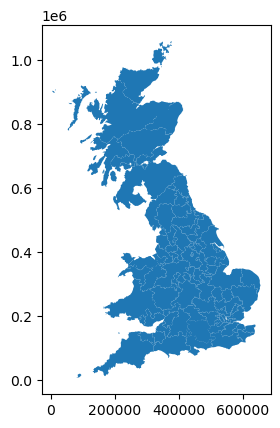

In [ ]:
minor_FLOP_polygons.plot()

In [ ]:
# groupby minor flop
fes2024_wp_minor_flop = fes2024_winter_peak.groupby("Minor FLOP").agg({"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})

In [ ]:
# add minor flop polygons
fes2024_wp_minor_flop = gpd.GeoDataFrame(fes2024_wp_minor_flop.merge(minor_FLOP_polygons[["Minor FLOP", "geometry", "GSP Group"]],
                                                                      left_on="Minor FLOP",
                                                                        right_on="Minor FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")

<Axes: >

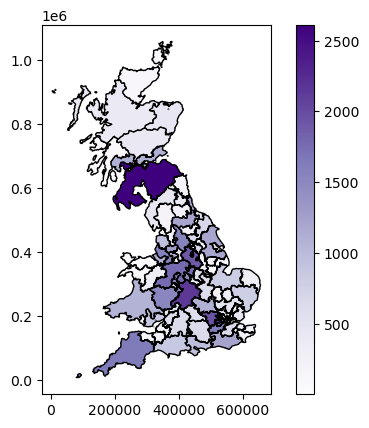

In [ ]:
fes2024_wp_minor_flop.plot(column="P(Gross)", cmap="Purples", legend=True, edgecolor="black")

In [ ]:
minor_FLOP_polygons["GSP Group"].unique().shape

(14,)

## Group by Major FLOP

In [ ]:
major_FLOP_polygons = gsp_polygons.dissolve(by="Major FLOP").reset_index()


In [ ]:
# groupby major flop
fes2024_wp_major_flop = fes2024_winter_peak.groupby("Major FLOP").agg({"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})

In [ ]:
# add major flop polygons
fes2024_wp_major_flop = gpd.GeoDataFrame(fes2024_wp_major_flop.merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")

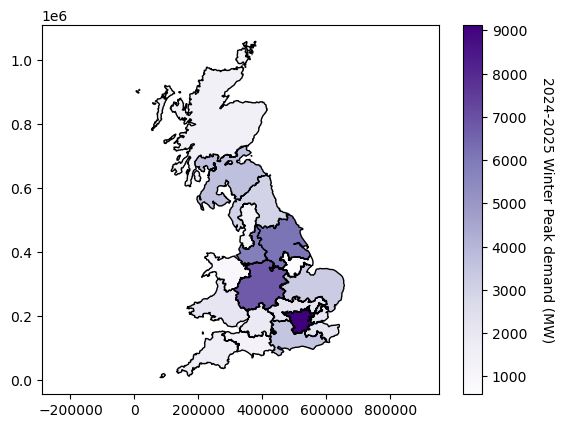

In [ ]:
ax=fes2024_wp_major_flop.plot(column="P(Gross)", cmap="Purples", legend=True, edgecolor="black")
cbar = ax.get_figure().get_axes()[1]
cbar.set_ylabel("2024-2025 Winter Peak demand (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

## Group by GSP Group

In [ ]:
fes2024_wp_major_flop.head()

,Major FLOP,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,GSP Group,geometry
0,A,9134.278885,1195.647333,530.148,1.017,3.452,717.330,_A,"MULTIPOLYGON (((499272 142548, 499230 142600, ..."
1,B,3497.827830,299.440241,1198.495,73.426,0.469,180.963,_H,"MULTIPOLYGON (((449470.92 102396.843, 449438.2..."
2,C,2144.666292,192.110474,923.545,239.613,0.474,676.853,_A,"MULTIPOLYGON (((532060.114 143491.058, 531951...."
3,D,2176.819603,92.612757,971.335,29.002,1.170,428.490,_H,"MULTIPOLYGON (((493191.034 206824.291, 493032...."
4,E,1258.536836,30.104401,1087.715,3.592,0.467,132.384,_L,"MULTIPOLYGON (((373948.409 80975.594, 373569.2..."


In [ ]:
# dno regions can be downloaded as a separate file or following the process above and dissolving on GSP Group

# groupby GSP Group
fes2024_wp_Group_flop = fes2024_wp_minor_flop.dissolve(by="GSP Group", aggfunc={"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})



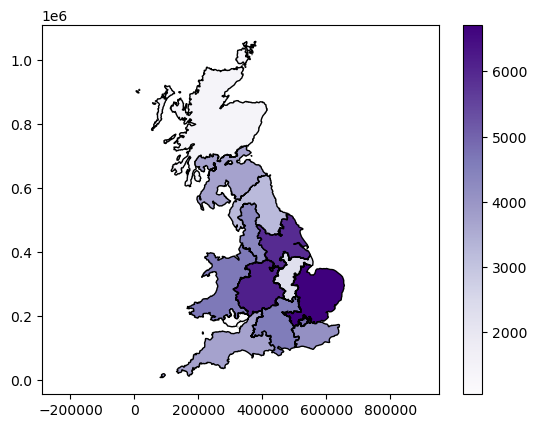

In [ ]:
ax = fes2024_wp_Group_flop.plot(column="P(Gross)", cmap="Purples", legend=True, edgecolor="black")
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

### Embedded solar and wind generation

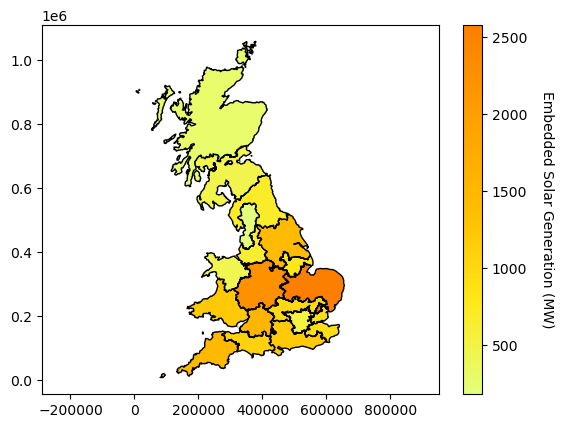

In [ ]:
ax = fes2024_wp_major_flop.plot(column="Embedded Solar", cmap="Wistia", legend=True, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[1]
cbar.set_ylabel("Embedded Solar Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

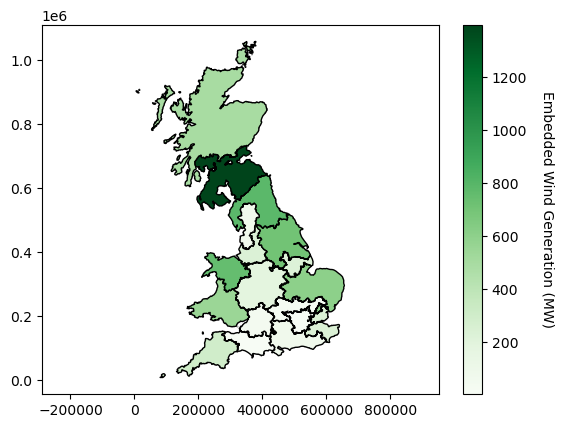

In [ ]:
ax = fes2024_wp_major_flop.plot(column="Embedded Wind", cmap="Greens", legend=True, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[1]
cbar.set_ylabel("Embedded Wind Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

## Import generation data

In [ ]:
large_gen_df = pd.read_csv("../Data/Generation/UK_2025_gen_above100MW_EPSG4326.csv",
                 index_col=0)
print(large_gen_df.shape)
# convert to geopandas using longitude and latitude columns
large_gen_gdf = gpd.GeoDataFrame(large_gen_df, geometry=gpd.points_from_xy(large_gen_df.lon, large_gen_df.lat), crs="EPSG:4326")

# remove gilbraltar 
large_gen_gdf = large_gen_gdf[large_gen_gdf.lat >= 40]

# convert to british national grid
large_gen_gdf = large_gen_gdf.to_crs(epsg=27700)

(118, 6)


In [ ]:
# assign large_gen_gdf to nearest polygon of major_FLOP_polygons
large_gen_gdf = gpd.sjoin_nearest(
    large_gen_gdf, 
    major_FLOP_polygons[["Major FLOP", "geometry"]], 
    how="left"
)
    
# drop the index column created by sjoin
large_gen_gdf = large_gen_gdf.drop(columns=["index_right"], errors="ignore")

In [ ]:
large_gen_gdf.shape

(117, 8)

In [ ]:
# group by type and major flop
large_gen_grouped = large_gen_gdf.groupby(["Major FLOP", "Fueltype"]).agg({'Capacity (MW)': 'sum'})
large_gen_grouped

Capacity (MW)
Major FLOP Fueltype                    
A          Natural Gas           1267.0
B          Natural Gas           1465.0
           Wind                   400.0
C          Natural Gas           3990.0
           Solar                  378.3
           Wind                  1070.0
D          Natural Gas           1490.0
E          Nuclear               5284.0
F          Natural Gas           1045.0
G          Natural Gas           1258.0
H          Natural Gas           4241.0
           Wind                   228.0
J          Natural Gas           4043.0
           Nuclear               1320.0
           Wind                  6959.8
K          Natural Gas           3633.0
           Wind                  1061.0
L          Natural Gas            236.0
M          Hydro                 2112.0
           Natural Gas           2015.0
           Wind                   576.0
N          Natural Gas           1855.0
           Wind                   254.0
P          Natural Gas           5462.0
           Solid Biomass         2718.0
           Wind                  1300.0
Q          Natural Gas            509.8
           Solid Biomass          299.0
           Wind                  5165.2
R          Nuclear               2676.0
S          Natural Gas           1008.0
           Nuclear               1370.0
           Wind                  3776.4
T          Hydro                  913.0
           Natural Gas           1653.0
           Wind                  4003.4

In [ ]:
large_gen_grouped.xs('Wind', level='Fueltype')

,Capacity (MW)
Major FLOP,
B,400.0
C,1070.0
H,228.0
J,6959.8
K,1061.0
M,576.0
N,254.0
P,1300.0
Q,5165.2


In [ ]:
large_wind_major_flop_polygons = gpd.GeoDataFrame(large_gen_grouped.xs('Wind', level='Fueltype').merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")


<Axes: >

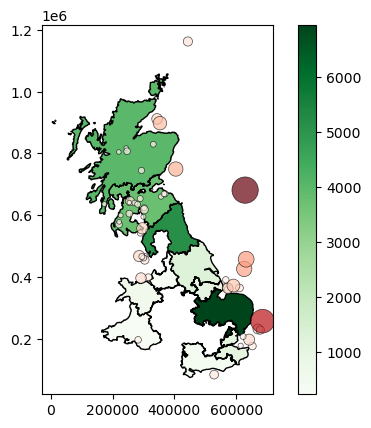

In [ ]:
ax = large_wind_major_flop_polygons.plot(column="Capacity (MW)", cmap="Greens", legend=True, edgecolor="black")

# add points from large_gen_gdf with point size related to capacity
wind_gen = large_gen_gdf[large_gen_gdf["Fueltype"]=='Wind']
wind_gen.plot(
    ax=ax, 
    column="Capacity (MW)", 
    markersize=wind_gen["Capacity (MW)"] / 10,  # Scale factor to adjust size
    cmap="Reds",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5
)